In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, BaseLineDataLoaderManager, GraphDataLoaderManager
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel, SimpleGCNModel, GCNLSTMModel
from src.evaluation import Evaluator

# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 14
lag_num         = 4

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    # quantiles           = [0.1,0.25, 0.5, 0.75, 0.9],
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    temporal_frequency='d',

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    lag_column          = 'incidence',  
    verbose             = 0  ,

    time_index_d= True,

    feature_popdens     = True,
    # feature_gisd        = True,
    # feature_popage      = True,
    # feature_popsize     = True,
    feature_kreise_classes= True
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )

from src.dataloading import CrossValidationEpiConfig, FoldCollection

cv_config = CrossValidationEpiConfig(
    min_date         = '2020-03-02',
    max_date         = '2023-01-01',
    num_folds        = 6,
    fold_step        = 1,
    train_periods    = 6,   # 6 months training
    val_periods      = 1,   # 1 month val
    test_periods     = 1,   # 1 month test
    expansion_method = 'rolling_window',
    unit             = 'm', # monthly folds for daily data
)


In [2]:
print(cv_config)

 Fold  |    Min Date    |   Train/Val    |    Val/Test    |    Max Date   
--------------------------------------------------------------------------
  0    |   2020-03-02   |   2020-09-02   |   2020-10-02   |   2020-11-02  
  1    |   2020-04-02   |   2020-10-02   |   2020-11-02   |   2020-12-02  
  2    |   2020-05-02   |   2020-11-02   |   2020-12-02   |   2021-01-02  
  3    |   2020-06-02   |   2020-12-02   |   2021-01-02   |   2021-02-02  
  4    |   2020-07-02   |   2021-01-02   |   2021-02-02   |   2021-03-02  
  5    |   2020-08-02   |   2021-02-02   |   2021-03-02   |   2021-04-02  


In [3]:
baselinedata = BaseLineDataLoaderManager(epidata_orchestrator)

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]
# baseline_models = [persistence]

baseline_evaluation = Evaluator(baseline_models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:01<00:00, 815.80it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


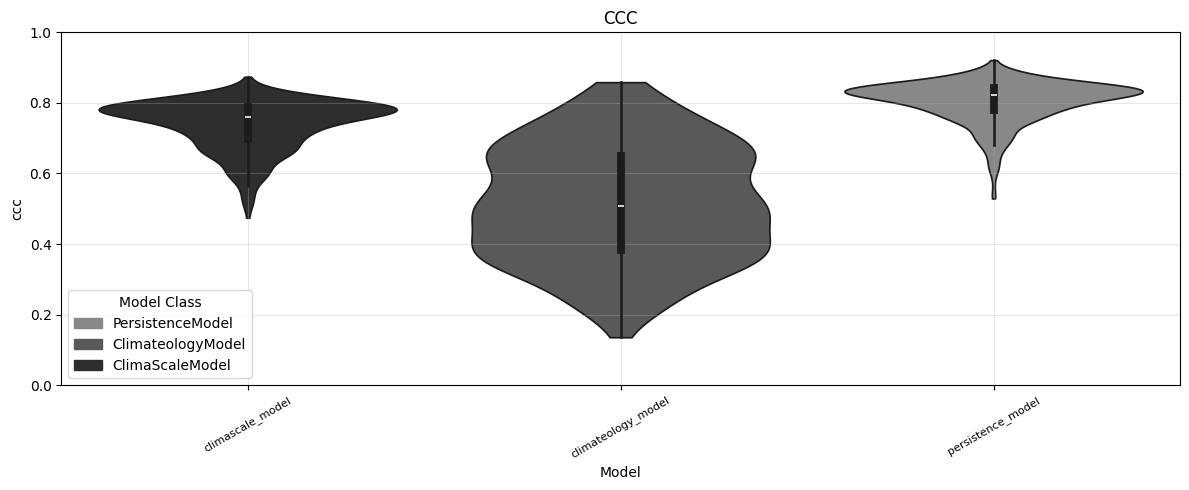

In [4]:
baseline_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'violin',vmin = 0, vmax = 1).show()

In [5]:
graphloader1 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test3').build()
graphloader2 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test1').build()
graphloader3 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test2').build()
graphloader4 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()


In [ ]:
from src.models import GCN2Model, DecoupledGCNModel


==                   spatial1                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 14), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.2111   |   0.8493   |    v     |           |
|  002  |   0.1734   |   0.7226   |    v     |           |
|  003  |   0.1634   |   0.7254   |          |   1/20    |
|  004  |   0.1591   |   0.7165   |    v     |           |
|  005  |   0.1558   |   0.6804   |    v     |           |
|  006  |   0.1529   |   0.6468   |    v     |           |
|  007  |   0.1506   |   0.6644   |          |   1/20    |
|  008  |   0.1492   |   0.6211   |    v     |           |
|  009  |   0.1473   |   0.6106   |    v     |           |
|  010  |   0.1472   |   0.5944   |    v     |           |
|  011  |   0.1464   |   0.6000   |          |   1/20    |
|  012  |   0.1454   |   0.5885   |    

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3951
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 405.06it/s]


Test loss: 0.2660
forecasted ✓

==                   spatial2                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 14), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.2024   |   0.8833   |    v     |           |
|  002  |   0.1741   |   0.8142   |    v     |           |
|  003  |   0.1612   |   0.7509   |    v     |           |
|  004  |   0.1561   |   0.7183   |    v     |           |
|  005  |   0.1516   |   0.6892   |    v     |           |
|  006  |   0.1470   |   0.6656   |    v     |           |
|  007  |   0.1444   |   0.6401   |    v     |           |
|  008  |   0.1408   |   0.6353   |    v     |           |
|  009  |   0.1400   |   0.6047   |    v     |           |
|  010  |   0.1406   |   0.6010   |    v     |           |
|  011  |   0.1382   |   0.6046   |          |   1/20    |
|  012

...

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3594
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:00<00:00, 388.27it/s]

Test loss: 0.2770
forecasted ✓


DecoupledGCNModel(name='spatial4')

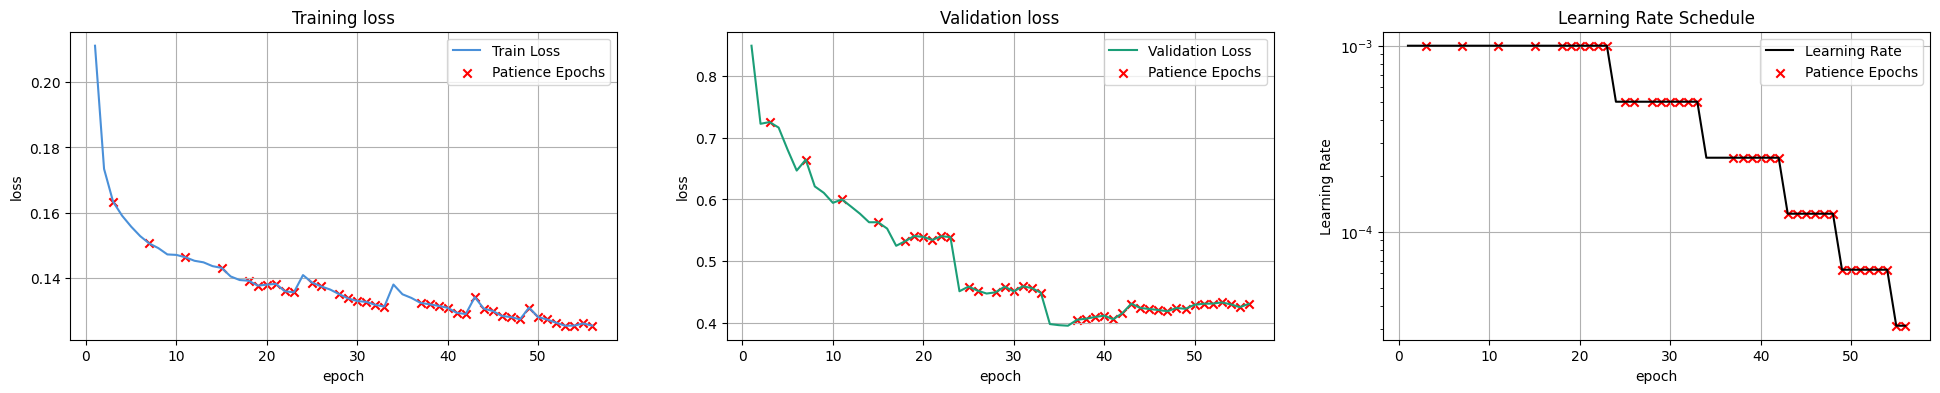

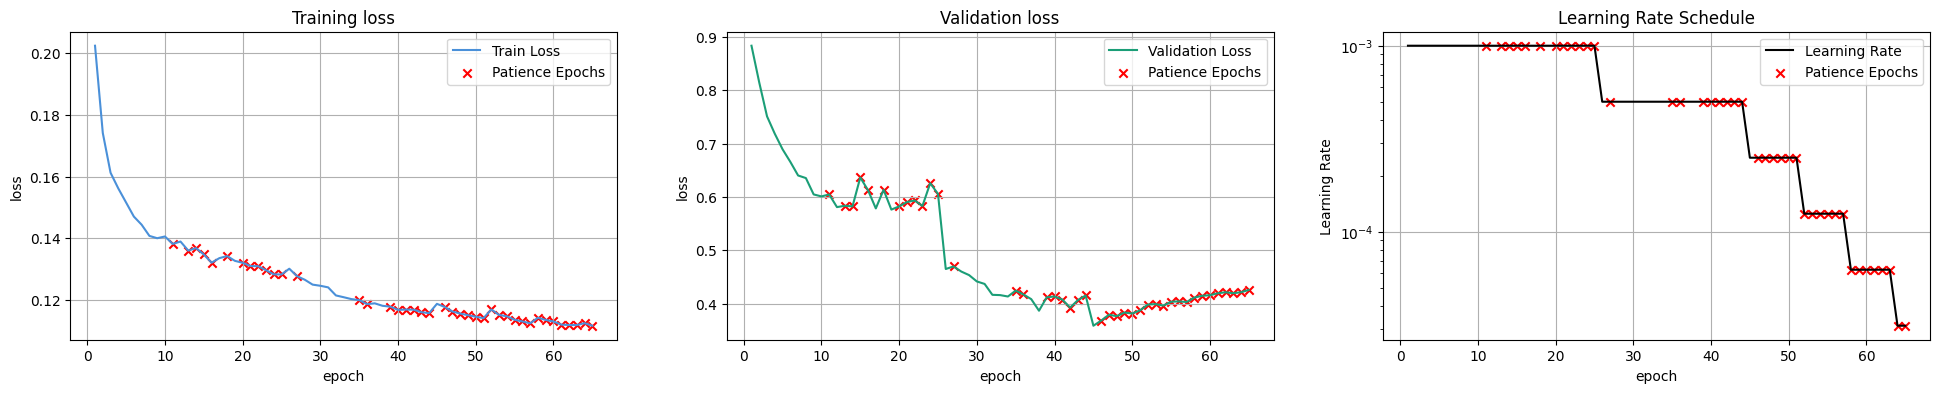

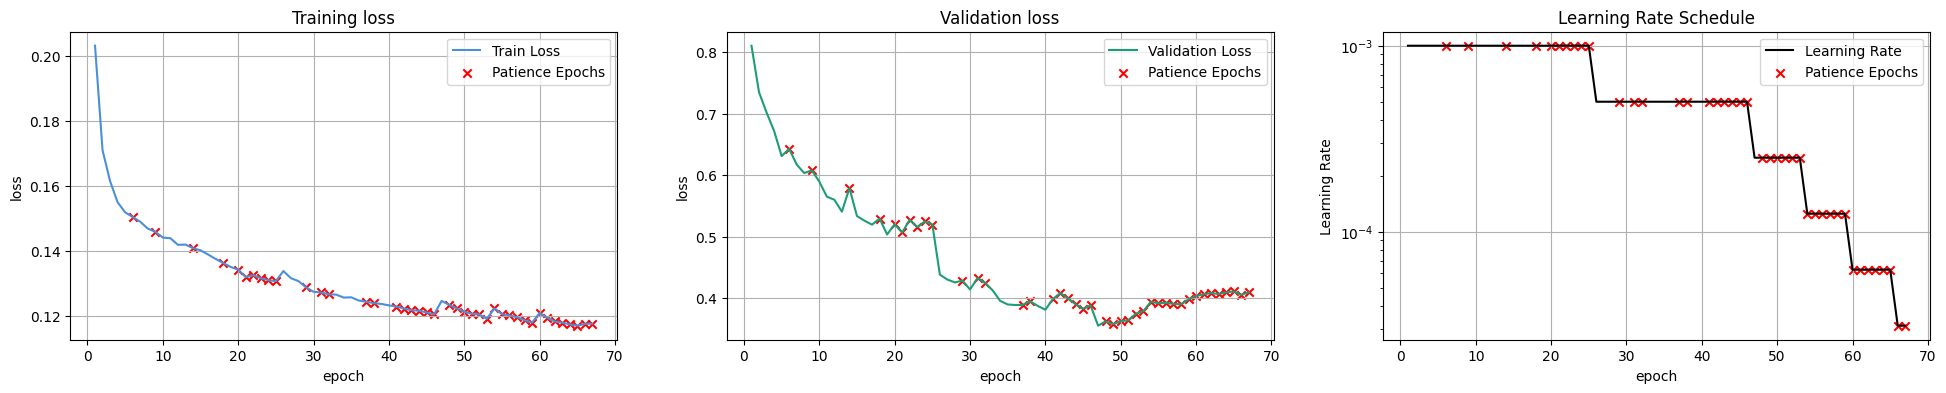

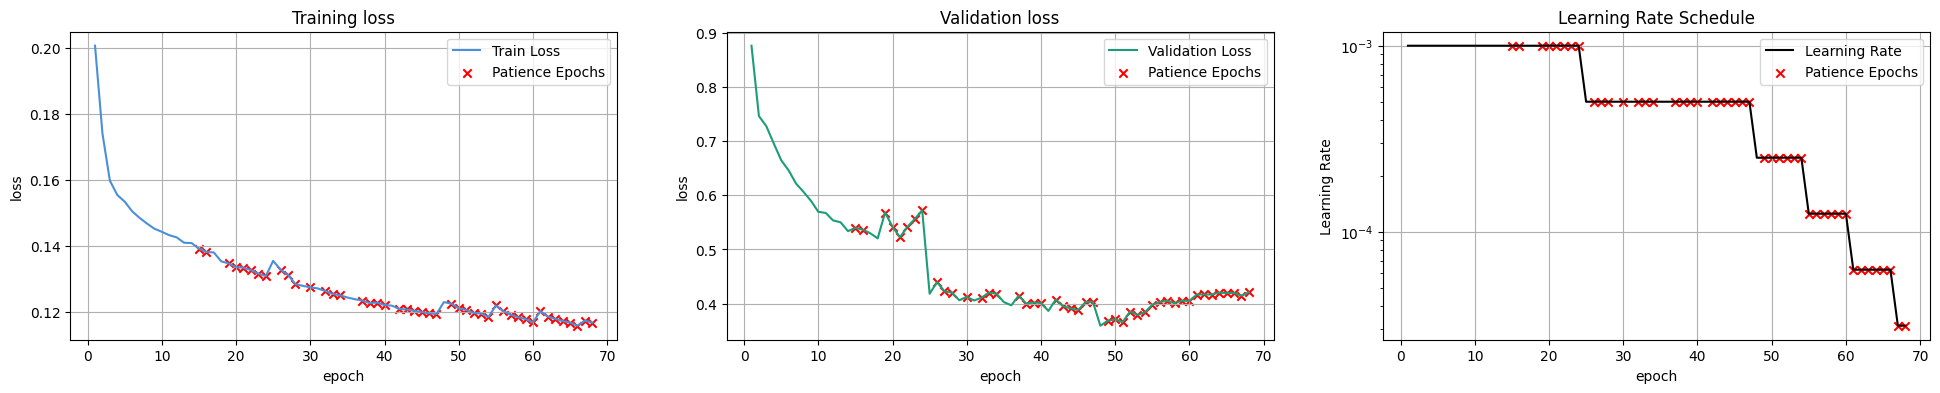

In [7]:
global_hparams = {
    'lr'        : 0.001,
    'n_epochs'  : 100,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 5},
    'patience'          : 20,    
}

model1 = DecoupledGCNModel(graphloader1, name = 'spatial1', verbose = 2)
model1.set_model_hparams()
model1.set_global_hparams(**global_hparams)
model1.train()
model1.forecast()

model2 = DecoupledGCNModel(graphloader2, name = 'spatial2', verbose = 2)
model2.set_model_hparams()
model2.set_global_hparams(**global_hparams)
model2.train()
model2.forecast()

model3 = DecoupledGCNModel(graphloader3, name = 'spatial3', verbose = 2)
model3.set_model_hparams()
model3.set_global_hparams(**global_hparams)
model3.train()
model3.forecast()

model4 = DecoupledGCNModel(graphloader4, name = 'spatial4', verbose = 2)
model4.set_model_hparams()
model4.set_global_hparams(**global_hparams)
model4.train()
model4.forecast()

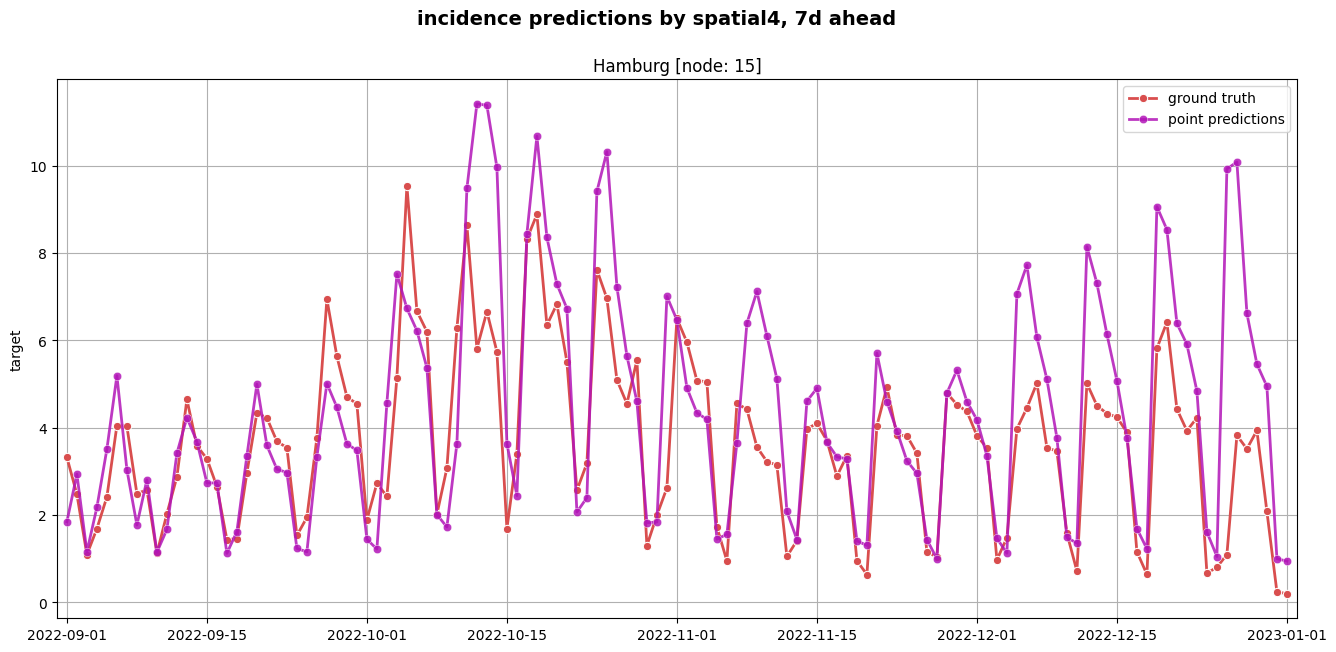

In [8]:
model4.show_forecasts(15).show()

In [11]:
models = [model1, model3, model4]
# models  = [model1, model2]

model_evaluation = Evaluator(baseline_models + models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2400/2400 [00:03<00:00, 764.77it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


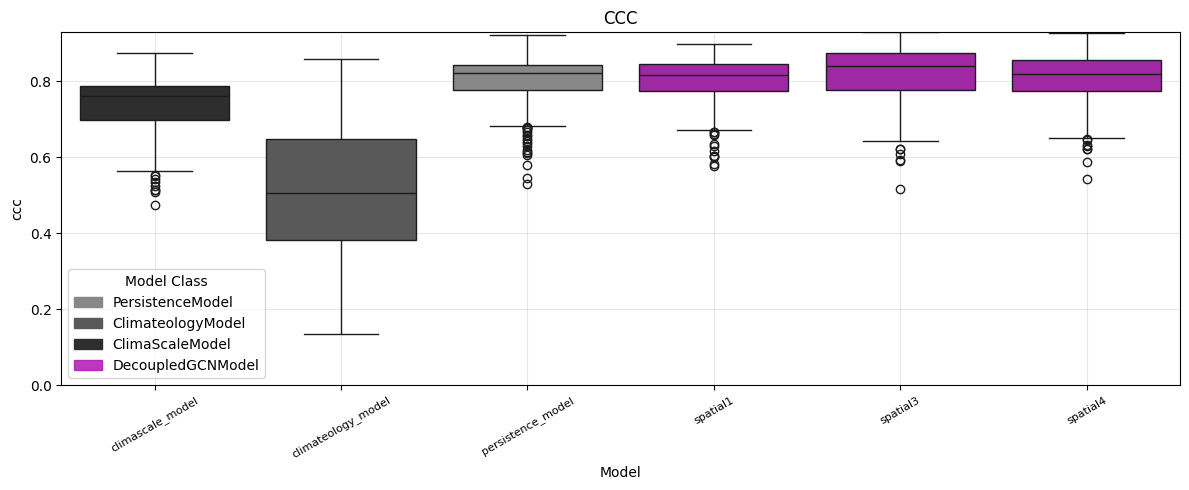

In [12]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'box', vmin = 0, log=False).show()

In [13]:
def model_ranking(
    evaluator,
    metric:  str  = 'ccc',
    horizon: int  = 0,
    dataset: str  = 'test',
) -> None:
    
    metrics = evaluator.data_compilation.get_data(horizon, dataset)['metrics']
    id_col  = evaluator.id_col

    # wide: one column per model
    df = metrics.pivot_table(index=id_col, columns='model', values=metric)
    model_cols = df.columns.tolist()

    # rank per node (1 = best)
    df_rank = df.rank(axis=1, ascending=False, method='min')

    # winner per node
    df['winner']  = df[model_cols].idxmax(axis=1)
    df['margin']  = df[model_cols].max(axis=1) - df[model_cols].apply(
        lambda r: r.nlargest(2).iloc[1], axis=1
    )

    # ── 1. win counts ─────────────────────────────────────────────────
    print(f"{'='*45}")
    print(f"  NODE WIN COUNTS  —  metric: {metric.upper()}")
    print(f"{'='*45}")
    win_counts = df['winner'].value_counts()
    for model, count in win_counts.items():
        pct = count / len(df) * 100
        bar = '█' * int(pct / 2)
        print(f"  {model:<25} {count:>4}  ({pct:5.1f}%)  {bar}")

    # ── 2. mean rank per model ────────────────────────────────────────
    print(f"\n{'='*45}")
    print(f"  MEAN RANK PER MODEL  (1 = best)")
    print(f"{'='*45}")
    mean_ranks = df_rank.mean().sort_values()
    for model, rank in mean_ranks.items():
        print(f"  {model:<25} {rank:.3f}")

    # ── 3. mean metric on own winning nodes ──────────────────────────
    print(f"\n{'='*45}")
    print(f"  MEAN {metric.upper()} ON NODES WHERE EACH MODEL WINS")
    print(f"{'='*45}")
    for model in model_cols:
        own_nodes  = df[df['winner'] == model]
        own_score  = own_nodes[model].mean()
        rival_best = own_nodes[[m for m in model_cols if m != model]].max(axis=1).mean()
        print(f"  {model:<25}  own: {own_score:.3f}  rival best: {rival_best:.3f}  gap: {own_score - rival_best:+.3f}")

    # ── 4. margin distribution ────────────────────────────────────────
    print(f"\n{'='*45}")
    print(f"  MARGIN DISTRIBUTION (winner - runner-up)")
    print(f"{'='*45}")
    print(f"  median : {df['margin'].median():.4f}")
    print(f"  mean   : {df['margin'].mean():.4f}")
    print(f"  >0.05  : {(df['margin'] > 0.05).mean():.1%} of nodes")
    print(f"  >0.10  : {(df['margin'] > 0.10).mean():.1%} of nodes")

In [14]:

model_ranking(model_evaluation, metric='ccc')

  NODE WIN COUNTS  —  metric: CCC
  spatial3                   217  ( 54.2%)  ███████████████████████████
  persistence_model           75  ( 18.8%)  █████████
  spatial4                    75  ( 18.8%)  █████████
  spatial1                    32  (  8.0%)  ████
  climateology_model           1  (  0.2%)  

  MEAN RANK PER MODEL  (1 = best)
  spatial3                  1.840
  spatial4                  2.555
  spatial1                  2.833
  persistence_model         2.908
  climascale_model          5.020
  climateology_model        5.845

  MEAN CCC ON NODES WHERE EACH MODEL WINS
  climascale_model           own: nan  rival best: nan  gap: +nan
  climateology_model         own: 0.828  rival best: 0.808  gap: +0.021
  persistence_model          own: 0.812  rival best: 0.785  gap: +0.028
  spatial1                   own: 0.773  rival best: 0.760  gap: +0.013
  spatial3                   own: 0.852  rival best: 0.834  gap: +0.018
  spatial4                   own: 0.835  rival best: 0.8

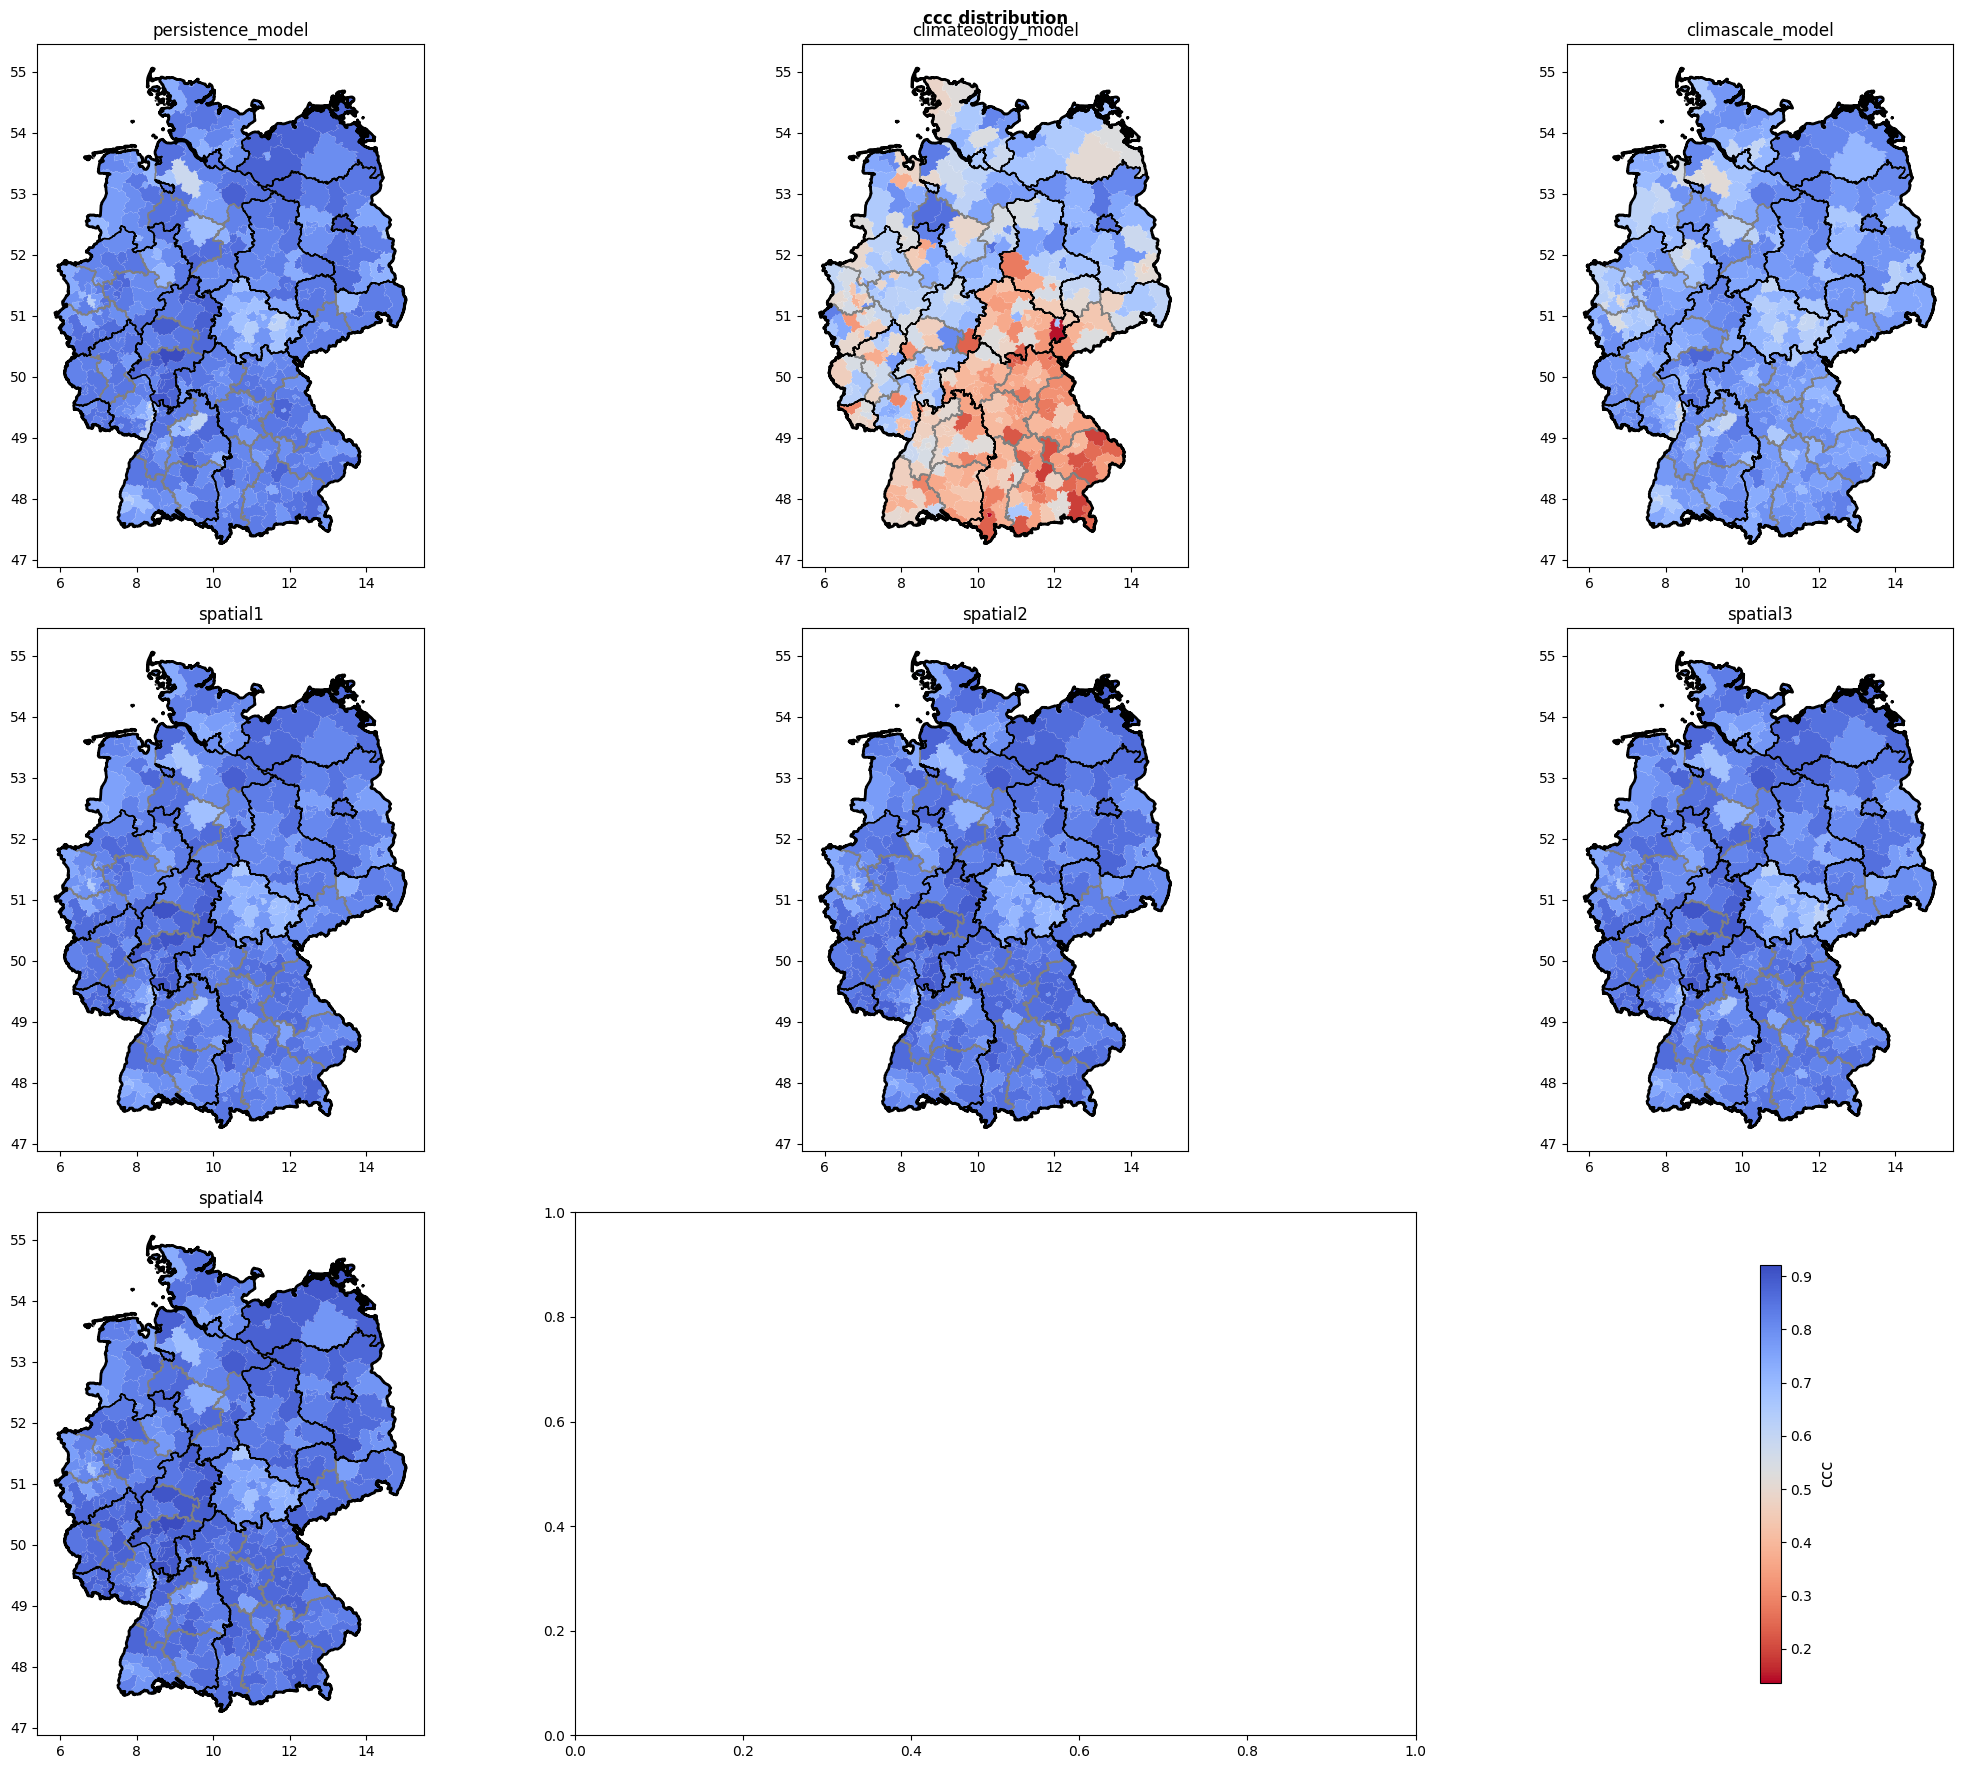

In [ ]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'map', vmin = 0, log=False, reverse_scale=True)

In [ ]:
metrics = ['ccc']


metrics_df = model_evaluation.data_compilation.get_data(0,'test')['metrics']

model_cols = list(metrics_df['model'].unique())

for metric in metrics:
    df_long = metrics_df[['nuts_node','model',metric]]
    df_wide = df_long.pivot_table(index = 'nuts_node', columns = 'model', values = metric).reset_index(drop = False).reset_index(drop = True)
    df_wide['best'] = df_wide[model_cols].idxmax(axis=1)

In [ ]:
# How much better is the best model than second best?
df_wide['best_score']   = df_wide[model_cols].max(axis=1)
df_wide['second_score'] = df_wide[model_cols].apply(
    lambda row: row.nlargest(2).iloc[1], axis=1
)
df_wide['margin'] = df_wide['best_score'] - df_wide['second_score']

# What fraction of nodes have a meaningful margin?
print(df_wide['margin'].describe())
print(f"Nodes with margin > 0.02: {(df_wide['margin'] > 0.02).mean():.1%}")
print(f"Nodes with margin > 0.05: {(df_wide['margin'] > 0.05).mean():.1%}")

# Replot best model only where margin exceeds threshold
threshold = 0.02
df_wide['best_significant'] = df_wide.apply(
    lambda row: row['best'] if row['margin'] > threshold else 'unclear', axis=1
)

count    400.000000
mean       0.010652
std        0.007052
min        0.000017
25%        0.005166
50%        0.009712
75%        0.015110
max        0.038286
Name: margin, dtype: float64
Nodes with margin > 0.02: 10.2%
Nodes with margin > 0.05: 0.0%


In [ ]:
# Who wins among the decisive nodes?
decisive = df_wide[df_wide['margin'] > 0.05]
print(decisive['best'].value_counts())
print(decisive['best'].value_counts(normalize=True).round(3))

Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)


<Axes: >

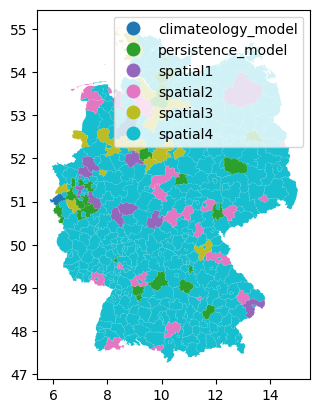

In [ ]:
import seaborn as sns 

import pandas as pd
shp = epidata_orchestrator._data_context.shapedata_node

shp = pd.merge(shp, df_wide, on = 'nuts_node')

shp.plot(column = 'best', legend = True)

In [ ]:
metrics = model_evaluation.data_compilation.get_data(0, 'test')['metrics']
df = metrics.pivot_table(index=model_evaluation.id_col, columns='model', values='ccc')
print((df['spatial4'] - df['persistence_model']).describe().round(4))

count    400.0000
mean       0.0275
std        0.0227
min       -0.0476
25%        0.0133
50%        0.0263
75%        0.0391
max        0.1393
dtype: float64


In [ ]:
df['delta'] = df['spatial4'] - df['persistence_model']

# top beneficiaries
print(df['delta'].nlargest(10))

# worst nodes — where spatial4 actually hurts
print(df[df['delta'] < 0]['delta'].describe().round(4))
print(f"Nodes where spatial4 hurts: {(df['delta'] < 0).sum()} ({(df['delta'] < 0).mean():.1%})")

nuts_node
165    0.139349
158    0.110128
39     0.101850
203    0.094510
396    0.091792
186    0.086669
97     0.086101
66     0.085429
48     0.083350
293    0.081094
Name: delta, dtype: float64
count    30.0000
mean     -0.0140
std       0.0113
min      -0.0476
25%      -0.0189
50%      -0.0094
75%      -0.0056
max      -0.0004
Name: delta, dtype: float64
Nodes where spatial4 hurts: 30 (7.5%)


In [ ]:
df[df['delta'] < 0]['delta']

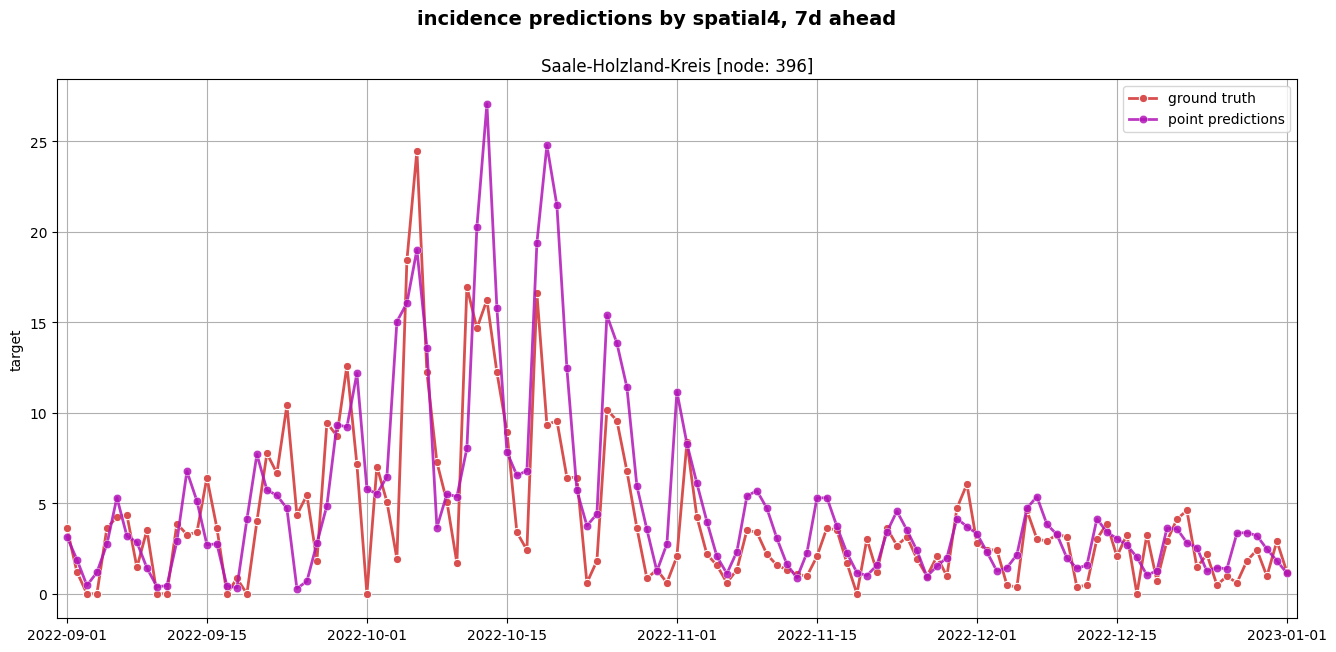

In [ ]:
model4.show_forecasts(396).show()

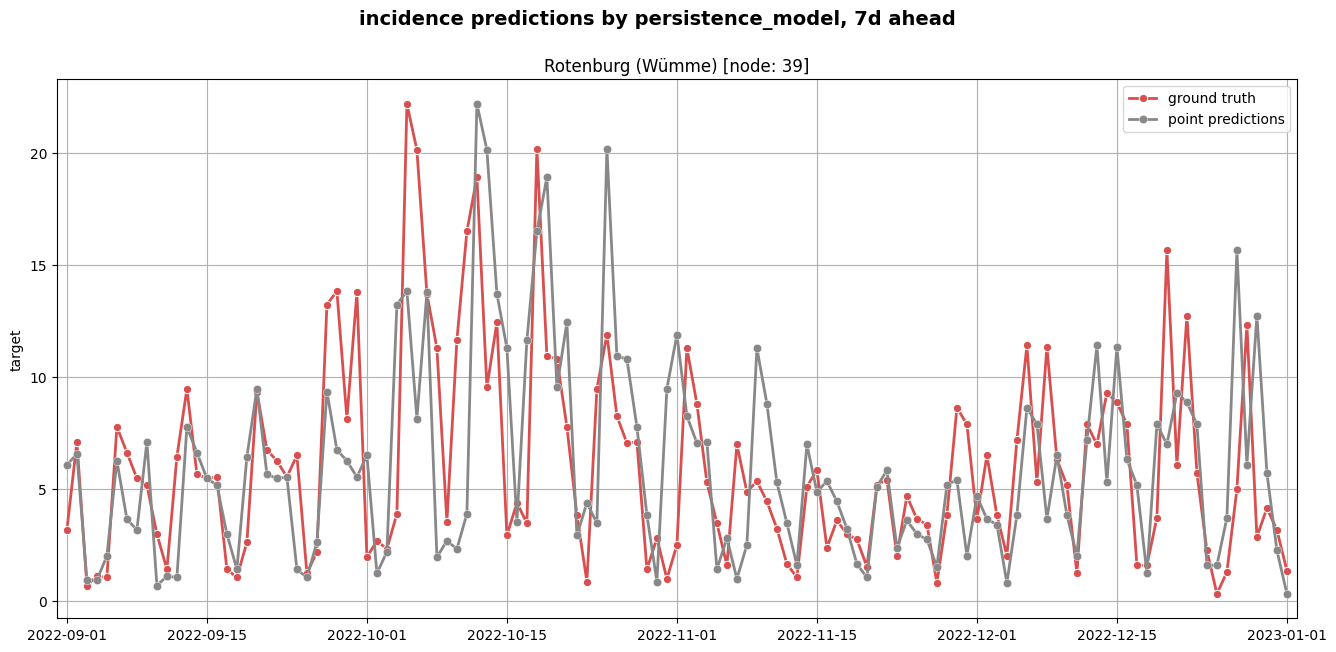

In [ ]:
persistence.show_forecasts(39).show()

In [ ]:
model_sel = metrics_sel[['nuts_node','spatial1','spatial2','spatial3']]
print(model_sel[(model_sel[['spatial1','spatial2','spatial3']] < 0.6).any(axis=1)]['nuts_node'].index)

KeyError: "['spatial2', 'spatial3'] not in index"

(-0.7502293674309588, 0.4165605514437629)

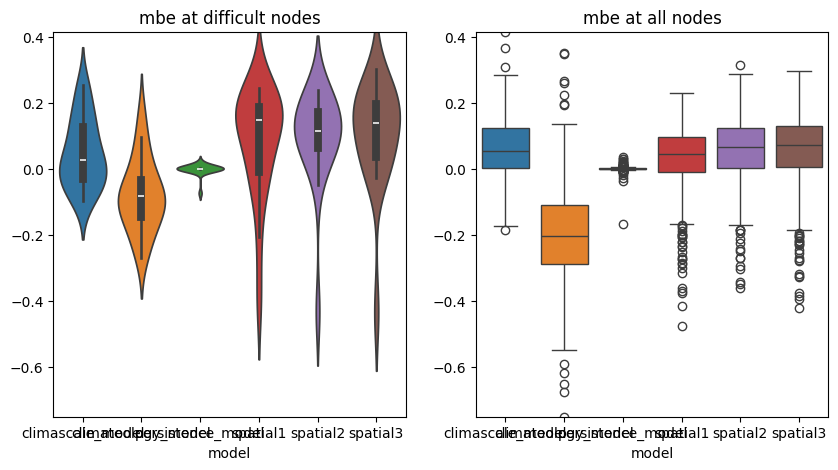

In [ ]:
import matplotlib.pyplot as plt

metric = 'mbe'
metrics = model_evaluation.data_compilation.get_data(0,'test')['metrics']
metrics_sel = metrics[['nuts_node','model',metric]]
metrics_sel = metrics_sel.pivot_table(columns = 'model', values = metric, index = 'nuts_node').reset_index(drop = False)
metrics_sel1= metrics_sel[metrics_sel['nuts_node'].isin(difficult_nodes)]
metrics_sel1 = metrics_sel1.set_index('nuts_node')

lim1, lim2 = metrics[metric].min(), metrics[metric].max()

# control:
metrics_sel2= metrics_sel[~metrics_sel['nuts_node'].isin(difficult_nodes)]
metrics_sel2 = metrics_sel2.set_index('nuts_node')

fig, axes = plt.subplots(1,2, figsize = (10,5))

sns.violinplot(metrics_sel1, ax = axes[0])
sns.boxplot(metrics_sel2,ax = axes[1])

axes[0].set_title(f'{metric} at difficult nodes')
axes[1].set_title(f'{metric} at all nodes')

axes[0].set_ylim(lim1,lim2)
axes[1].set_ylim(lim1,lim2)

<Axes: xlabel='model'>

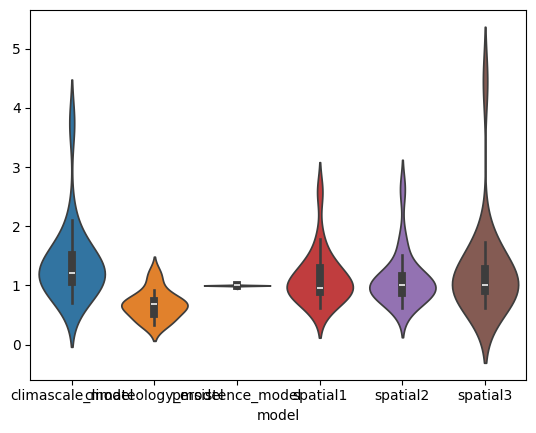

In [ ]:

metrics_sel['gap_idenity']    = metrics_sel['persistence_model'] - metrics_sel['spatial1']
metrics_sel['gap_geononself'] = metrics_sel['persistence_model'] - metrics_sel['spatial2']
metrics_sel['gap_geoself']    = metrics_sel['persistence_model'] - metrics_sel['spatial3']
metrics_sel['gap_ig']         = metrics_sel['spatial1'] - metrics_sel['spatial2']

<Axes: >

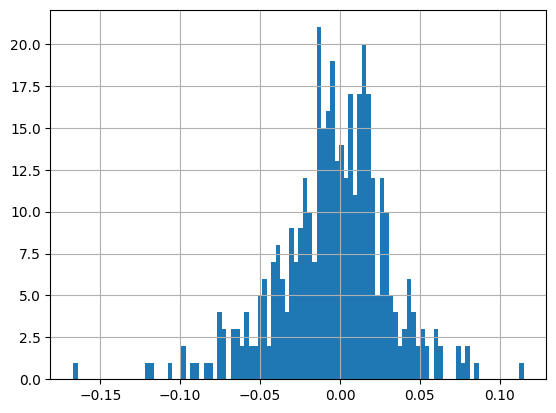

In [ ]:
metrics_sel